In [ ]:
#bài 1: cài đặt thư viện OpenCV và Pillow
!pip install opencv-python Pillow

import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

print('OpenCV version:', cv2.__version__)
import PIL; print('Pillow version:', PIL.__version__)

OpenCV version: 4.11.0
Pillow version: 12.0.0


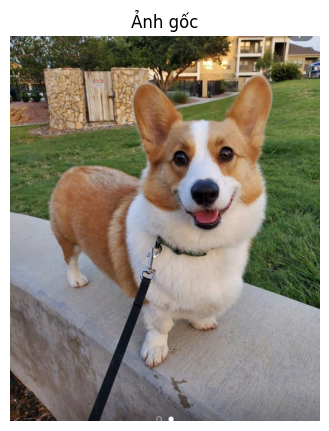

Kích thước ảnh: (914, 735, 3)
Đã lưu ảnh dưới định dạng PNG
Đã lưu ảnh dưới định dạng BMP bằng Pillow


In [3]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
#Bài 2: Đọc ảnh và hiển thị ảnh
img_bgr = cv2.imread('lab1.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Hiển thị ảnh
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title('Ảnh gốc')
plt.axis('off')
plt.show()

print('Kích thước ảnh:', img_rgb.shape)  # (height, width, channels)

# Lưu ảnh với định dạng khác (PNG)
cv2.imwrite('lab1_saved.png', img_bgr)
print('Đã lưu ảnh dưới định dạng PNG')

# Hoặc dùng Pillow
pil_img = Image.fromarray(img_rgb)
pil_img.save('lab1_pillow.bmp')   # lưu thành BMP
print('Đã lưu ảnh dưới định dạng BMP bằng Pillow')


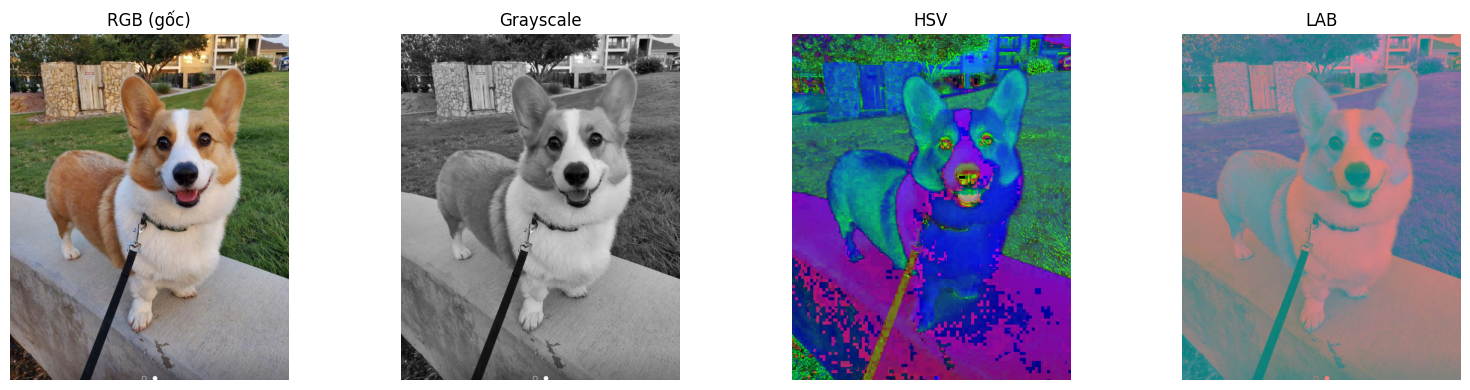

In [4]:
#bài 3: Chuyển đổi không gian màu
# RGB → Grayscale
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# RGB → HSV
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# RGB → LAB
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_rgb);          axes[0].set_title('RGB (gốc)');    axes[0].axis('off')
axes[1].imshow(gray, cmap='gray');axes[1].set_title('Grayscale');    axes[1].axis('off')
axes[2].imshow(hsv);              axes[2].set_title('HSV');          axes[2].axis('off')
axes[3].imshow(lab);              axes[3].set_title('LAB');          axes[3].axis('off')

plt.tight_layout()
plt.show()

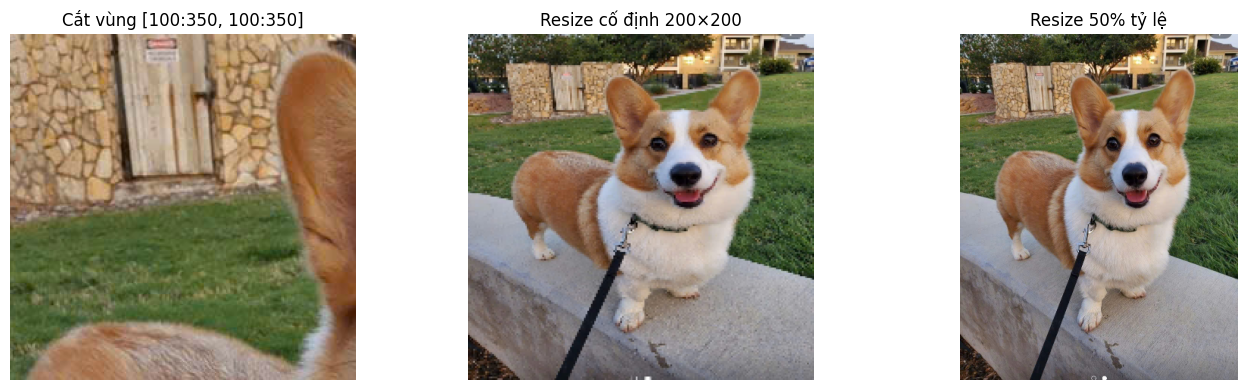

Kích thước ảnh gốc: (914, 735)
Kích thước sau crop: (250, 250)
Kích thước sau resize 50%: (457, 367)


In [5]:
#Bài 4: Cắt ảnh và thay đổi kích thước
# Cắt vùng ảnh: img[y1:y2, x1:x2]
crop = img_rgb[100:350, 100:350]

# Thay đổi kích thước cố định
resized_fixed = cv2.resize(img_rgb, (200, 200))

# Thay đổi theo tỷ lệ (50%)
scale = 0.5
h, w = img_rgb.shape[:2]
resized_scale = cv2.resize(img_rgb, (int(w * scale), int(h * scale)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(crop);          axes[0].set_title('Cắt vùng [100:350, 100:350]'); axes[0].axis('off')
axes[1].imshow(resized_fixed); axes[1].set_title('Resize cố định 200×200');      axes[1].axis('off')
axes[2].imshow(resized_scale); axes[2].set_title('Resize 50% tỷ lệ');            axes[2].axis('off')

plt.tight_layout()
plt.show()

print('Kích thước ảnh gốc:', img_rgb.shape[:2])
print('Kích thước sau crop:', crop.shape[:2])
print('Kích thước sau resize 50%:', resized_scale.shape[:2])

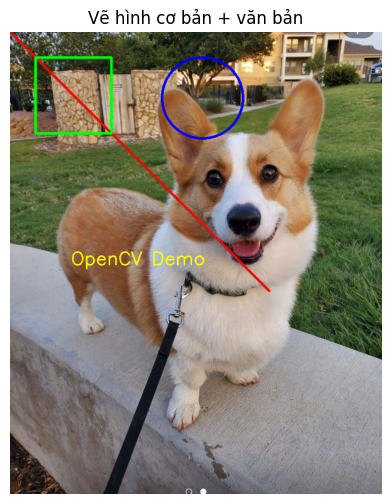

Đã lưu result_drawing.png


In [6]:
#Bài 5: Vẽ hinh cơ bản và thêm văn bản
# Tạo bản sao để vẽ lên (tránh thay đổi ảnh gốc)
canvas = img_rgb.copy()

# Vẽ đường thẳng: cv2.line(img, pt1, pt2, color, thickness)
cv2.line(canvas, (0, 0), (512, 512), (255, 0, 0), 3)       # màu đỏ

# Vẽ hình chữ nhật: cv2.rectangle(img, pt1, pt2, color, thickness)
cv2.rectangle(canvas, (50, 50), (200, 200), (0, 255, 0), 3) # màu xanh lá

# Vẽ hình tròn: cv2.circle(img, center, radius, color, thickness)
cv2.circle(canvas, (380, 130), 80, (0, 0, 255), 3)          # màu xanh dương

# Thêm văn bản: cv2.putText(img, text, org, font, scale, color, thickness)
cv2.putText(canvas, 'OpenCV Demo', (120, 460),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(canvas)
plt.title('Vẽ hình cơ bản + văn bản')
plt.axis('off')
plt.show()

# Lưu kết quả
cv2.imwrite('result_drawing.png', cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))
print('Đã lưu result_drawing.png')